In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import Libraries

!pip install -q xgboost==2.1.1 h5py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import h5py
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.6 MB/s eta 0:00:00


In [3]:
# Define paths

paths = {
    "train": "/content/drive/My Drive/Cybersecurity/Embedding_Concatenate/Concatenated_Train_embeddings.csv",
    "test":  "/content/drive/My Drive/Cybersecurity/Embedding_Concatenate/Concatenated_Test_embeddings.csv",
    "val":   "/content/drive/My Drive/Cybersecurity/Embedding_Concatenate/Concatenated_Val_embeddings.csv"
}

# Load CSVs

train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

print(train_df.shape, val_df.shape, test_df.shape)

# Remap 23-class labels → 4-class labels

def remap_labels(series):
    return series.apply(
        lambda x:
            0 if x == 0 else
            1 if x in [1,2,3,4] else
            2 if 5 <= x <= 18 else
            3
    )

train_df["Label"] = remap_labels(train_df["Label"])
val_df["Label"]   = remap_labels(val_df["Label"])
test_df["Label"]  = remap_labels(test_df["Label"])

# SAVE THE NEW REMAPPED CSVs

save_dir = "/content/Remapped_4Class"
os.makedirs(save_dir, exist_ok=True)

train_path_new = f"{save_dir}/Train_4class.csv"
val_path_new   = f"{save_dir}/Val_4class.csv"
test_path_new  = f"{save_dir}/Test_4class.csv"

train_df.to_csv(train_path_new, index=False)
val_df.to_csv(val_path_new, index=False)
test_df.to_csv(test_path_new, index=False)

print("Saved remapped CSVs to:", save_dir)

(586532, 385) (195448, 385) (195519, 385)
Saved remapped CSVs to: /content/Remapped_4Class


In [4]:
# Split X and y

X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val = val_df["Label"].values.astype(int)

X_test = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test = test_df["Label"].values.astype(int)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Shapes:
Train: (586532, 384) (586532,)
Val:   (195448, 384) (195448,)
Test:  (195519, 384) (195519,)


In [6]:
# Prepare for ROC

classes = np.array([0,1,2,3])
n_classes = 4
print("Detected classes ({}): {}".format(n_classes, classes))

y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin   = label_binarize(y_val,   classes=classes)
y_test_bin  = label_binarize(y_test,  classes=classes)

Detected classes (4): [0 1 2 3]


In [7]:
# Train XGBoost (GPU)

params = {
    "objective": "multi:softprob",
    "num_class": n_classes,
    "tree_method": "gpu_hist",
    "predictor": "gpu_predictor",
    "learning_rate": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "mlogloss"
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

start = time.time()
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dval, "validation")],
    callbacks=[xgb.callback.EarlyStopping(rounds=30)]
)
print("Training time:", time.time() - start)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [11:22:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [11:22:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation-mlogloss:1.31695
[1]	validation-mlogloss:1.25436
[2]	validation-mlogloss:1.19747
[3]	validation-mlogloss:1.14559
[4]	validation-mlogloss:1.09802
[5]	validation-mlogloss:1.05424
[6]	validation-mlogloss:1.01385
[7]	validation-mlogloss:0.97647
[8]	validation-mlogloss:0.94182
[9]	validation-mlogloss:0.90966
[10]	validation-mlogloss:0.87972
[11]	validation-mlogloss:0.85182
[12]	validation-mlogloss:0.82577
[13]	validation-mlogloss:0.80142
[14]	validation-mlogloss:0.77865
[15]	validation-mlogloss:0.75733
[16]	validation-mlogloss:0.73735
[17]	validation-mlogloss:0.71862
[18]	validation-mlogloss:0.70104
[19]	validation-mlogloss:0.68453
[20]	validation-mlogloss:0.66902
[21]	validation-mlogloss:0.65442
[22]	validation-mlogloss:0.64069
[23]	validation-mlogloss:0.62778
[24]	validation-mlogloss:0.61561
[25]	validation-mlogloss:0.60415
[26]	validation-mlogloss:0.59334
[27]	validation-mlogloss:0.58314
[28]	validation-mlogloss:0.57353
[29]	validation-mlogloss:0.56446
[30]	validation-mlog

In [8]:
# Save the Model

model_dir = "/content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class"
os.makedirs(model_dir, exist_ok=True)

bst.save_model(f"{model_dir}/xgboost_4class.json")
print("Model saved.")

Model saved.


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [11:39:54] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [9]:
# Predict on test set and produce classification report

dtest = xgb.DMatrix(X_test)
y_proba = bst.predict(dtest)
y_pred = y_proba.argmax(axis=1)

print("\nTEST REPORT:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)


TEST REPORT:

              precision    recall  f1-score   support

           0     0.1368    0.0006    0.0012     25519
           1     0.7890    0.9999    0.8820     56715
           2     0.9176    1.0000    0.9570    111324
           3     0.8444    0.9521    0.8950      1961

    accuracy                         0.8690    195519
   macro avg     0.6719    0.7382    0.6838    195519
weighted avg     0.7777    0.8690    0.8099    195519

Confusion matrix:
 [[    16  15167   9992    344]
 [     3  56712      0      0]
 [     4      0 111320      0]
 [    94      0      0   1867]]


In [10]:
# Print Train/Val/Test Reports

def eval_split(name, X, y):
    d = xgb.DMatrix(X)
    p = bst.predict(d).argmax(axis=1)
    print(f"\n{name} REPORT:")
    print(classification_report(y, p, digits=4))

eval_split("TRAIN", X_train, y_train)
eval_split("VAL", X_val, y_val)
eval_split("TEST", X_test, y_test)


TRAIN REPORT:
              precision    recall  f1-score   support

           0     0.9920    0.0096    0.0190     77336
           1     0.7890    1.0000    0.8821    170147
           2     0.9177    1.0000    0.9571    333922
           3     0.8180    0.9992    0.8996      5127

    accuracy                         0.8694    586532
   macro avg     0.8792    0.7522    0.6894    586532
weighted avg     0.8893    0.8694    0.8111    586532


VAL REPORT:
              precision    recall  f1-score   support

           0     0.2473    0.0009    0.0018     25748
           1     0.7892    1.0000    0.8822     56682
           2     0.9176    0.9999    0.9570    111309
           3     0.7364    0.9614    0.8340      1709

    accuracy                         0.8680    195448
   macro avg     0.6726    0.7406    0.6687    195448
weighted avg     0.7905    0.8680    0.8084    195448


TEST REPORT:
              precision    recall  f1-score   support

           0     0.1368    0.0006


===== Confusion Matrix: Train =====
[[   741  45493  29962   1140]
 [     0 170146      1      0]
 [     2      0 333920      0]
 [     4      0      0   5123]]
Saved: /content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class/confusion_matrix_train.png


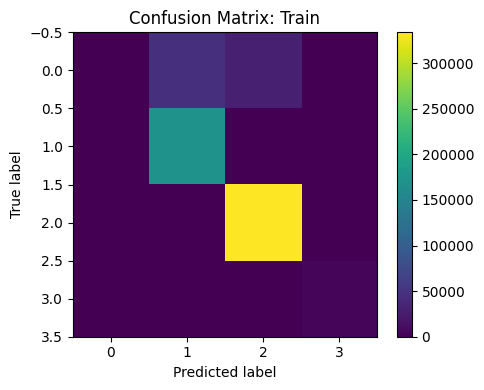


===== Confusion Matrix: Validation =====
[[    23  15143   9996    586]
 [     0  56682      0      0]
 [     4      0 111303      2]
 [    66      0      0   1643]]
Saved: /content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class/confusion_matrix_val.png


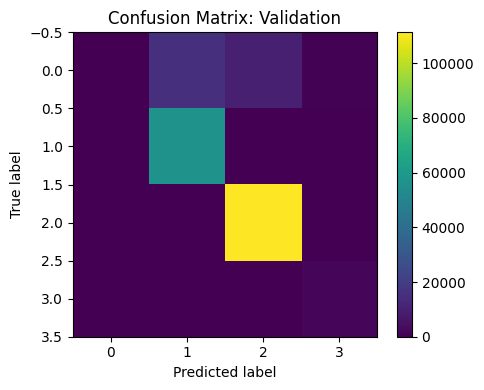


===== Confusion Matrix: Test =====
[[    16  15167   9992    344]
 [     3  56712      0      0]
 [     4      0 111320      0]
 [    94      0      0   1867]]
Saved: /content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class/confusion_matrix_test.png


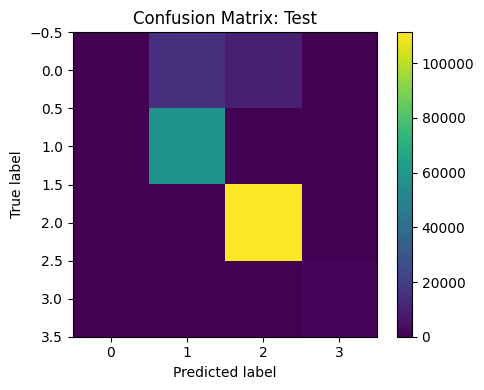

In [12]:
# Confusion Matrix for Train, Validation, and Test

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_save_path = "/content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class"

def plot_cm_and_save(cm, title, filename):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()

    # Save figure
    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")

    plt.show()

def generate_cm(name, X, y, filename):
    d = xgb.DMatrix(X)
    pred = bst.predict(d).argmax(axis=1)
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename)

# Train
generate_cm("Train", X_train, y_train, "confusion_matrix_train.png")

# Validation
generate_cm("Validation", X_val, y_val, "confusion_matrix_val.png")

# Test
generate_cm("Test", X_test, y_test, "confusion_matrix_test.png")

Per-class AUCs:
 Class 0: AUC = 0.6296
 Class 1: AUC = 0.9451
 Class 2: AUC = 0.9406
 Class 3: AUC = 0.9990
Macro AUC: 0.8785455293102893


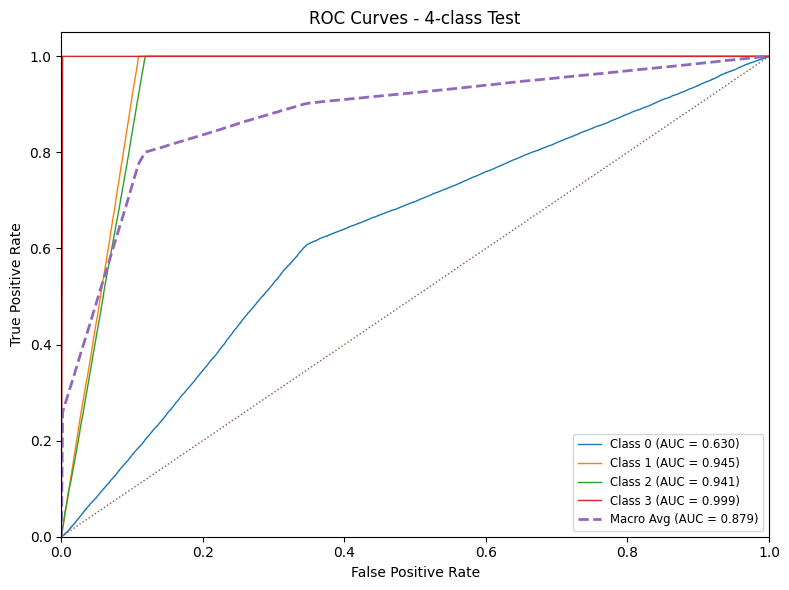

ROC curve saved to: /content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class/roc_curve_test.png


In [13]:
# ROC curves & AUC (one-vs-rest, per-class + macro AUC)

fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curve and AUC per class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print("Per-class AUCs:")
for i in range(n_classes):
    print(f" Class {classes[i]}: AUC = {roc_auc[i]:.4f}")
print("Macro AUC:", roc_auc["macro"])

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["macro"], tpr["macro"], linewidth=2, linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], linewidth=1, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test")
plt.legend(loc="lower right", fontsize='small')
plt.tight_layout()

roc_path = "/content/drive/My Drive/Cybersecurity/Ensemble model training/XGBoost_4class/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()

print("ROC curve saved to:", roc_path)